<a href="https://colab.research.google.com/github/14marcos1/ELT578/blob/main/FIXO_PLACA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'ELT578'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 40 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 11.67 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Salvo: placa_retificada.png

Imagem da placa retificada (na tela):


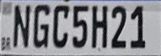

In [13]:
import cv2
import numpy as np
import os
import shutil
from google.colab.patches import cv2_imshow # Obrigatório para exibir imagens no Colab

# 1. Configuração do Ambiente e Git
repo_name = 'ELT578'
if os.path.exists(repo_name): shutil.rmtree(repo_name)
!git clone https://github.com/14marcos1/{repo_name}.git > /dev/null
os.chdir(repo_name)

# 2. Carrega a Imagem (Mudei para o nome que o Git listou antes)
nome_arquivo = 'PLACA6L.jpg'
img = cv2.imread(nome_arquivo)

if img is None:
    print(f"Erro: '{nome_arquivo}' não encontrado.")
    print("Arquivos no Git:", os.listdir())
else:
    # 3. Pré-processamento e Detecção de Contornos (Resumo do seu código)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blur, 75, 200)

    # Encontra contornos e pega o maior (que deve ser a placa)
    cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:1]

    if len(cnts) == 0:
        print("Erro: Não foi possível detectar o contorno da placa.")
        cv2_imshow(edged) # Mostra o Canny para ajudar a debugar
    else:
        # Aproxima o contorno para 4 pontos (os cantos da placa)
        peri = cv2.arcLength(cnts[0], True)
        approx = cv2.approxPolyDP(cnts[0], 0.02 * peri, True)

        # Se não achou 4 pontos exatos, usa os pontos ordenados que você mandou antes
        if len(approx) == 4:
            pontos = approx.reshape(4, 2)
        else:
            print("Aviso: Detecção automática falhou, usando pontos manuais.")
            pontos = np.array([[235., 487.], [367., 506.], [347., 565.], [247., 552.]], dtype="float32")

        # 4. Ordena os pontos (Cima-Esquerda, Cima-Direita, Baixo-Direita, Baixo-Esquerda)
        s = pontos.sum(axis=1)
        rect = np.zeros((4, 2), dtype="float32")
        rect[0] = pontos[np.argmin(s)] # Cima-Esquerda
        rect[2] = pontos[np.argmax(s)] # Baixo-Direita

        diff = np.diff(pontos, axis=1)
        rect[1] = pontos[np.argmin(diff)] # Cima-Direita
        rect[3] = pontos[np.argmax(diff)] # Baixo-Esquerda

        # Calcula a nova largura e altura da placa retificada
        (tl, tr, br, bl) = rect
        widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
        widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
        maxWidth = max(int(widthA), int(widthB))

        heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
        heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
        maxHeight = max(int(heightA), int(heightB))

        # Define os pontos de destino (a placa "reta")
        dst = np.array([
            [0, 0],
            [maxWidth - 1, 0],
            [maxWidth - 1, maxHeight - 1],
            [0, maxHeight - 1]
        ], dtype="float32")

        # 5. Aplica a Transformação de Perspectiva (O tal Perspective Transform)
        M = cv2.getPerspectiveTransform(rect, dst)
        top_down = cv2.warpPerspective(img, M, (maxWidth, maxHeight))

        # --- A CORREÇÃO QUE VOCÊ PEDIU ESTÁ AQUI ---
        # Salva o arquivo (como no seu print)
        cv2.imwrite("placa_retificada.png", top_down)
        print("Salvo: placa_retificada.png")

        # EXIBE A IMAGEM NA TELA DO COLAB
        print("\nImagem da placa retificada (na tela):")
        cv2_imshow(top_down)
        # -------------------------------------------